# Final: Xception + CVAE + SSIM — Opción B (β-schedule fijo + β_max reducido)

Variante con HPs de Optuna pero con **3 cambios** para evitar el posterior collapse que se vio
con los HPs literales del trial ganador.

**HPs base (de Optuna):**
- `lr_backbone` = 1.354e-06
- `lr_cvae` = 8.723e-04
- `z_dim` = 192
- `cond_emb_dim` = 32
- `batch_size` = 16

**Cambios respecto al trial original (Opción B):**
1. **β-schedule fijo en épocas absolutas**: rampa lineal de la época 1 a la 12 (igual que en Optuna),
   y después se MANTIENE en β_max hasta la época 40. Antes la rampa se estiraba a 40 épocas y
   el modelo nunca llegaba a régimen pleno hasta el final.
2. **β_max reducido**: 0.435 → **0.18**. El valor original era muy alto para este loss
   (β·KLD del mismo orden que la reconstrucción) y empujaba al colapso del posterior.
3. **λ_L1 subido**: 0.0104 → **0.05**. Penaliza más fuerte que el decoder colapse a una imagen
   constante (lo que se vio en la corrida anterior).

**Setup:**
- Subsample: 10%
- Épocas: 40
- Loss: SSIM + L1 + KLD
- Fine-tune: bloques 11-14 de Xception


In [1]:
# Sin instalaciones extra: Xception viene en keras.applications

## Imports y config

In [2]:
import os
import json
import time
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.applications import Xception
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TF version: {tf.__version__}")
print(f"GPUs: {len(tf.config.list_physical_devices('GPU'))}")

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

2026-04-28 04:28:00.341488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777350480.548159      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777350480.609112      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777350481.147317      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777350481.147358      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777350481.147362      23 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: 2


## Hiperparámetros (mejores de Optuna)

In [3]:
# HPs base de Optuna + 3 ajustes anti-colapso (Opción B)
BEST_PARAMS_PATH = "/kaggle/input/datasets/carloscanamejoy/best-params-ssim/best_params_ssim.json"

if os.path.exists(BEST_PARAMS_PATH):
    with open(BEST_PARAMS_PATH) as f:
        bp = json.load(f)["best_params"]
    print(f"Cargado desde: {BEST_PARAMS_PATH}")
else:
    # Optuna ganador (con ajustes para evitar colapso)
    bp = {
        "lr_backbone": 1.3540658782530271e-06,
        "lr_cvae":     0.000872261525233455,
        "beta_max":    0.18,        # <-- AJUSTE B: era 0.4348, bajado para no aplastar el posterior
        "lambda_l1":   0.05,        # <-- AJUSTE B: era 0.0104, subido para penalizar el colapso a constante
        "z_dim":       192,
        "cond_emb_dim": 32,
        "batch_size":  16,
    }
    print("Usando valores con ajustes anti-colapso")

LR_BACKBONE = bp["lr_backbone"]
LR_CVAE     = bp["lr_cvae"]
BETA_MAX    = bp["beta_max"]
LAMBDA_L1   = bp["lambda_l1"]
Z_DIM       = bp["z_dim"]
COND_EMB_DIM= bp["cond_emb_dim"]
BATCH_SIZE  = bp["batch_size"]

# config fija
EPOCHS         = 40
BETA_START     = 1e-6
BETA_RAMP_END  = 12          # <-- AJUSTE B: β llega a β_max en época 12 y se mantiene
COND_DIM       = 8
SUBSAMPLE_FRAC = 0.10

print(f"\nHPs finales:")
for k, v in bp.items():
    print(f"  {k:14s} = {v}")
print(f"\nConfig:")
print(f"  epochs        = {EPOCHS}")
print(f"  beta_ramp_end = {BETA_RAMP_END} (después se mantiene en β_max)")
print(f"  subsample     = {SUBSAMPLE_FRAC*100:.0f}%")

Usando valores con ajustes anti-colapso

HPs finales:
  lr_backbone    = 1.3540658782530271e-06
  lr_cvae        = 0.000872261525233455
  beta_max       = 0.18
  lambda_l1      = 0.05
  z_dim          = 192
  cond_emb_dim   = 32
  batch_size     = 16

Config:
  epochs        = 40
  beta_ramp_end = 12 (después se mantiene en β_max)
  subsample     = 10%


## Cargar dataset y subsample al 10%

In [4]:
DATASET_PATH = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-complete/dataset-united.npz"
# Ajusta esta ruta al dataset donde subiste los pesos .h5 de tu Xception inverso
XCEPTION_WEIGHTS = "/kaggle/input/datasets/carloscanamejoy/weights-xception-model/modelo_xception_fulldatabaseV2.h5"

data = np.load(DATASET_PATH)
imgs = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)

N = len(imgs)
print(f"Dataset total: {N:,}")

rng = np.random.RandomState(SEED)
sub_idx = rng.choice(N, size=int(N * SUBSAMPLE_FRAC), replace=False)

imgs_sub = imgs[sub_idx]
params_sub_raw = params[sub_idx]

idx_all = np.arange(len(sub_idx))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

scaler = MinMaxScaler()
params_train = scaler.fit_transform(params_sub_raw[idx_train]).astype(np.float32)
params_val = scaler.transform(params_sub_raw[idx_val]).astype(np.float32)
params_test = scaler.transform(params_sub_raw[idx_test]).astype(np.float32)

print(f"Subsample 10%: {len(sub_idx):,}")
print(f"Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}")

Dataset total: 218,256
Subsample 10%: 21,825
Train: 15,277  Val: 3,274  Test: 3,274


## tf.data pipelines

In [5]:
def preprocess(img, param):
    # Xception espera 224x224 RGB (igual que el ViT, así no cambia el input shape)
    img_xc = tf.image.resize(img, (224, 224))
    img_xc = tf.image.grayscale_to_rgb(img_xc)
    img_target = tf.image.resize(img, (40, 40))
    return img_xc, param, img_target

train_ds = (
    tf.data.Dataset.from_tensor_slices((imgs_sub[idx_train], params_train))
    .shuffle(10000, seed=SEED)
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((imgs_sub[idx_val], params_val))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

for img_xc, param, img_target in train_ds.take(1):
    print(f"img_xc:     {img_xc.shape}  range [{img_xc.numpy().min():.2f}, {img_xc.numpy().max():.2f}]")
    print(f"param:      {param.shape}")
    print(f"img_target: {img_target.shape} range [{img_target.numpy().min():.2f}, {img_target.numpy().max():.2f}]")

I0000 00:00:1777350516.446653      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777350516.452596      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


img_xc:     (16, 224, 224, 3)  range [-1.00, 1.00]
param:      (16, 8)
img_target: (16, 40, 40, 1) range [-0.98, 0.99]


## Cargar Xception pre-entrenado

Construimos la arquitectura **completa** del modelo inverso (Xception backbone + GAP + Dense(8))
para poder cargar el `.h5` tal como fue guardado. Después extraemos solo el backbone para usarlo
en el CVAE.

Importante: usamos `weights=None` para evitar la descarga de pesos de ImageNet
(que falla en Save & Run sin internet).

In [6]:
# Estrategia: el .h5 fue guardado con el modelo "plano" (Xception expandido + GAP + Dense).
# Para que load_weights case nombre-a-nombre, construimos PRIMERO el modelo plano
# (sin anidar Xception como submodelo), cargamos pesos, y DESPUÉS extraemos el backbone
# reconstruyéndolo con los nombres de capa originales para usarlo dentro del CVAE.

# 1) Modelo plano para cargar el .h5 tal como fue guardado
#    Truco: usamos la API funcional encadenando la salida de Xception directamente
#    en lugar de envolverlo como un sub-Model. Esto deja todas las capas de Xception
#    en el nivel superior del modelo final.
_inp = Input(shape=(224, 224, 3), name="input_layer")
_xception_full = Xception(
    weights=None,
    include_top=False,
    input_tensor=_inp,   # <- clave: input_tensor en lugar de input_shape evita el wrapping
    pooling=None,
)
_x = _xception_full.output
_x = GlobalAveragePooling2D(name="global_average_pooling2d")(_x)
_x = Dense(8, activation="linear", name="dense")(_x)
_temp_model = Model(_inp, _x, name="functional")

# 2) Cargar pesos del modelo inverso preentrenado (ahora los nombres SÍ casan)
_temp_model.load_weights(XCEPTION_WEIGHTS)
print(f"Weights loaded OK from {XCEPTION_WEIGHTS}")

# 3) Para usar Xception como "backbone" dentro del CVAE, lo recortamos a partir
#    del modelo plano: tomamos input -> última capa convolucional de Xception
#    (la salida del block14_sepconv2_act, que es la entrada al GAP).
gap_layer = _temp_model.get_layer("global_average_pooling2d")
xception_output_tensor = gap_layer.input  # tensor (B, 7, 7, 2048)

backbone = Model(_temp_model.input, xception_output_tensor, name="xception_backbone")
print(f"Backbone extraído: input {backbone.input_shape} -> output {backbone.output_shape}")

del _temp_model

# 4) Fine-tune SOLO los últimos 4 bloques (block11..block14)
#    El resto (stem, bloques 1-10, skips de adaptación) queda congelado.
TRAINABLE_BLOCKS = {11, 12, 13, 14}

def _is_trainable(layer_name: str) -> bool:
    if not layer_name.startswith("block"):
        return False
    rest = layer_name[5:]
    num_str = ""
    for ch in rest:
        if ch.isdigit():
            num_str += ch
        else:
            break
    if not num_str:
        return False
    return int(num_str) in TRAINABLE_BLOCKS

n_train_layers = 0
n_total_layers = 0
for layer in backbone.layers:
    n_total_layers += 1
    if _is_trainable(layer.name):
        layer.trainable = True
        n_train_layers += 1
    else:
        layer.trainable = False

n_train_vars = sum(1 for _ in backbone.trainable_variables)
n_all_vars = len(backbone.variables)
print(f"Backbone Xception: {n_train_layers}/{n_total_layers} layers trainable")
print(f"                   {n_train_vars}/{n_all_vars} trainable vars")
print(f"Bloques 1-10 + stem: congelados | Bloques 11-14: trainable")

Weights loaded OK from /kaggle/input/datasets/carloscanamejoy/weights-xception-model/modelo_xception_fulldatabaseV2.h5
Backbone extraído: input (None, 224, 224, 3) -> output (None, 7, 7, 2048)
Backbone Xception: 31/132 layers trainable
                   40/234 trainable vars
Bloques 1-10 + stem: congelados | Bloques 11-14: trainable


## CVAE

In [7]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * lv)


class Encoder(layers.Layer):
    def __init__(self, z_dim=64, cond_emb_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.fc1 = Dense(512, activation="silu")
        self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)
        self.sampling = Sampling()

    def call(self, emb, ce):
        h = tf.concat([emb, ce], axis=-1)
        h = self.fc1(h)
        h = self.fc2(h)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        z = self.sampling([mu, lv])
        return mu, lv, z


class Prior(layers.Layer):
    def __init__(self, z_dim=64, cond_emb_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.cond_net = keras.Sequential([
            Dense(64, activation="silu"),
            Dense(128, activation="silu"),
            Dense(cond_emb_dim, activation="silu")
        ])
        self.fc_mu = Dense(z_dim)
        self.fc_lv = Dense(z_dim)

    def call(self, y):
        ce = self.cond_net(y)
        return self.fc_mu(ce), self.fc_lv(ce), ce


class Decoder(layers.Layer):
    def __init__(self, cond_emb_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.fc_in = Dense(512 * 5 * 5, activation="silu")
        self.reshape = layers.Reshape((5, 5, 512))

        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same")
        self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same")
        self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64, 4, strides=2, padding="same")
        self.bn3 = layers.BatchNormalization()

        self.res1_c1 = layers.Conv2D(64, 3, padding="same")
        self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same")
        self.res2_c2 = layers.Conv2D(64, 3, padding="same")

        self.out_conv = layers.Conv2D(1, 1, activation="tanh")

    def call(self, z, ce, training=None):
        x = self.fc_in(tf.concat([z, ce], axis=-1))
        x = self.reshape(x)
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x))
        x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x))
        x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)


class CVAE_Xception(Model):
    def __init__(self, backbone, z_dim=64, cond_dim=8, cond_emb_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        # Xception (include_top=False) entrega feature maps (B, 7, 7, 2048) -> GAP2D -> (B, 2048)
        self.gap = GlobalAveragePooling2D()
        self.encoder = Encoder(z_dim, cond_emb_dim)
        self.prior = Prior(z_dim, cond_emb_dim)
        self.decoder = Decoder(cond_emb_dim)

    def call(self, inputs, training=None):
        img_xc, y = inputs
        feats = self.backbone(img_xc, training=training)  # (B, 7, 7, 2048)
        emb = self.gap(feats)                              # (B, 2048)
        mu_p, lv_p, ce = self.prior(y)
        mu_q, lv_q, z = self.encoder(emb, ce)
        x_hat = self.decoder(z, ce, training=training)
        return x_hat, mu_q, lv_q, mu_p, lv_p

    def generate(self, y):
        mu_p, lv_p, ce = self.prior(y)
        z = mu_p
        return self.decoder(z, ce, training=False)


model = CVAE_Xception(backbone, z_dim=Z_DIM, cond_dim=COND_DIM, cond_emb_dim=COND_EMB_DIM)

dummy_img = tf.zeros((1, 224, 224, 3))
dummy_y = tf.zeros((1, COND_DIM))
_ = model([dummy_img, dummy_y], training=False)

print(f"Total params:    {model.count_params():,}")
print(f"Backbone params: {backbone.count_params():,}")
print(f"CVAE params:     {model.count_params() - backbone.count_params():,}")

I0000 00:00:1777350523.805223      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Total params:    27,965,193
Backbone params: 20,861,480
CVAE params:     7,103,713


## Loss y training steps

In [8]:
CKPT_PATH = "/kaggle/working/cvae_xception_optB.weights.h5"

opt_backbone = keras.optimizers.Adam(learning_rate=LR_BACKBONE)
opt_cvae = keras.optimizers.Adam(learning_rate=LR_CVAE)

backbone_vars = model.backbone.trainable_variables
cvae_vars = (model.encoder.trainable_variables +
             model.prior.trainable_variables +
             model.decoder.trainable_variables +
             model.gap.trainable_variables)

print(f"Backbone vars: {len(backbone_vars)}")
print(f"CVAE vars:     {len(cvae_vars)}")


def ssim_loss(y_true, y_pred):
    y_true_01 = (y_true + 1.0) / 2.0
    y_pred_01 = (y_pred + 1.0) / 2.0
    ssim_val = tf.image.ssim(y_true_01, y_pred_01, max_val=1.0)
    return 1.0 - ssim_val


@tf.function
def train_step(img_xc, y, img_target, beta):
    with tf.GradientTape() as tape:
        x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=True)

        ssim_per = ssim_loss(img_target, x_hat)
        ssim_val = tf.reduce_mean(ssim_per)
        l1_per = tf.reduce_mean(tf.abs(x_hat - img_target), axis=[1, 2, 3])
        l1_val = tf.reduce_mean(l1_per)
        recon = ssim_val + LAMBDA_L1 * l1_val

        vq = tf.exp(lv_q)
        vp = tf.exp(lv_p)
        kl_per_dim = 0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0)
        kld = tf.reduce_mean(kl_per_dim)

        loss = recon + beta * kld

    grads = tape.gradient(loss, backbone_vars + cvae_vars)
    g_backbone = grads[:len(backbone_vars)]
    g_cvae = grads[len(backbone_vars):]

    g_backbone = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in g_backbone]
    g_cvae = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in g_cvae]

    opt_backbone.apply_gradients([(g, v) for g, v in zip(g_backbone, backbone_vars) if g is not None])
    opt_cvae.apply_gradients([(g, v) for g, v in zip(g_cvae, cvae_vars) if g is not None])

    return loss, recon, kld


@tf.function
def val_step(img_xc, y, img_target, beta):
    x_hat, mu_q, lv_q, mu_p, lv_p = model([img_xc, y], training=False)

    ssim_val = tf.reduce_mean(ssim_loss(img_target, x_hat))
    l1_val = tf.reduce_mean(tf.abs(x_hat - img_target))
    recon = ssim_val + LAMBDA_L1 * l1_val

    vq = tf.exp(lv_q)
    vp = tf.exp(lv_p)
    kl_per_dim = 0.5 * (lv_p - lv_q + (vq + tf.square(mu_q - mu_p)) / vp - 1.0)
    kld = tf.reduce_mean(kl_per_dim)

    x_gen = model.generate(y)
    ssim_gen = tf.reduce_mean(ssim_loss(img_target, x_gen))
    l1_gen = tf.reduce_mean(tf.abs(x_gen - img_target))
    gen = ssim_gen + LAMBDA_L1 * l1_gen

    kl_mean_per_dim = tf.reduce_mean(kl_per_dim, axis=0)
    active = tf.reduce_mean(tf.cast(kl_mean_per_dim > 0.01, tf.float32))
    var_q = tf.reduce_mean(vq)
    gap = tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(mu_q - mu_p), axis=1)))

    return recon, kld, gen, active, var_q, gap

Backbone vars: 40
CVAE vars:     42


## Training loop

In [9]:
hist = {k: [] for k in [
    "train_loss", "train_recon", "train_kld",
    "val_recon", "val_kld", "val_gen", "kl_active", "var_q", "mu_gap", "beta"]}

best_gen = float("inf")

print(f"\n{'='*70}")
print(f"Training Xception OptB | SSIM+L1 | beta {BETA_START}->{BETA_MAX:.4f} (ramp ep1-{BETA_RAMP_END}) | {EPOCHS}ep | {len(sub_idx):,} imgs")
print(f"  LR backbone: {LR_BACKBONE:.2e}  LR cvae: {LR_CVAE:.2e}")
print(f"  z_dim: {Z_DIM}  cond_emb_dim: {COND_EMB_DIM}  batch: {BATCH_SIZE}")
print(f"  lambda_l1: {LAMBDA_L1:.4f}")
print(f"{'='*70}")

t_global = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # β-schedule en épocas ABSOLUTAS (Opción B): rampa hasta época BETA_RAMP_END, luego mantener
    if epoch <= BETA_RAMP_END:
        p = (epoch - 1) / max(1, (BETA_RAMP_END - 1))
        beta = BETA_START + (BETA_MAX - BETA_START) * p
    else:
        beta = BETA_MAX
    beta_t = tf.constant(beta, dtype=tf.float32)

    # train
    tl = tr = tk = 0.0
    n_batch = 0
    for img_xc, param, img_orig in train_ds:
        loss, rec, kld = train_step(img_xc, param, img_orig, beta_t)
        tl += loss.numpy(); tr += rec.numpy(); tk += kld.numpy()
        n_batch += 1
    tl /= n_batch; tr /= n_batch; tk /= n_batch

    # val
    vr = vk = vg = va = vv = vgap = 0.0
    n_val = 0
    for img_xc, param, img_orig in val_ds:
        r, k, g, a, v, gap = val_step(img_xc, param, img_orig, beta_t)
        vr += r.numpy(); vk += k.numpy(); vg += g.numpy()
        va += a.numpy(); vv += v.numpy(); vgap += gap.numpy()
        n_val += 1
    vr /= n_val; vk /= n_val; vg /= n_val
    va /= n_val; vv /= n_val; vgap /= n_val

    for k, v in zip(
        ["train_loss", "train_recon", "train_kld",
         "val_recon", "val_kld", "val_gen", "kl_active", "var_q", "mu_gap", "beta"],
        [tl, tr, tk, vr, vk, vg, va, vv, vgap, beta]):
        hist[k].append(v)

    tag = ""
    if vg < best_gen:
        best_gen = vg
        model.save_weights(CKPT_PATH)
        tag = " *"
    if va < 0.15:
        tag += " COLLAPSE"

    el = time.time() - t0
    print(f"Ep[{epoch:3d}/{EPOCHS}] b={beta:.4f}"
          f" | rec={tr:.4f} kld={tk:.4f}"
          f" | Vr={vr:.4f} Vk={vk:.4f} Vg={vg:.4f}"
          f" | act={va:.2f} gap={vgap:.1f} vQ={vv:.3f}"
          f" | {el:.0f}s" + tag)

tm = (time.time() - t_global) / 60
print(f"\nDone in {tm:.1f} min. Best gen={best_gen:.4f}")


Training Xception OptB | SSIM+L1 | beta 1e-06->0.1800 (ramp ep1-12) | 40ep | 21,825 imgs
  LR backbone: 1.35e-06  LR cvae: 8.72e-04
  z_dim: 192  cond_emb_dim: 32  batch: 16
  lambda_l1: 0.0500
Ep[  1/40] b=0.0000 | rec=0.9004 kld=382.2975 | Vr=0.9172 Vk=1.2011 Vg=0.9186 | act=1.00 gap=18.1 vQ=0.762 | 212s *
Ep[  2/40] b=0.0164 | rec=0.8741 kld=0.1430 | Vr=0.8687 Vk=0.2113 Vg=0.8925 | act=0.99 gap=9.0 vQ=0.923 | 191s *
Ep[  3/40] b=0.0327 | rec=0.8471 kld=0.0995 | Vr=0.8007 Vk=0.0637 Vg=0.8359 | act=0.94 gap=4.5 vQ=1.476 | 190s *
Ep[  4/40] b=0.0491 | rec=0.8212 kld=0.0885 | Vr=0.7815 Vk=0.0715 Vg=0.8348 | act=0.95 gap=5.3 vQ=1.558 | 190s *
Ep[  5/40] b=0.0655 | rec=0.7958 kld=0.0818 | Vr=0.7529 Vk=0.0689 Vg=0.8288 | act=0.96 gap=5.2 vQ=1.425 | 190s *
Ep[  6/40] b=0.0818 | rec=0.7700 kld=0.0680 | Vr=0.7478 Vk=0.0599 Vg=0.8267 | act=0.94 gap=4.9 vQ=1.351 | 191s *
Ep[  7/40] b=0.0982 | rec=0.7490 kld=0.0627 | Vr=0.7337 Vk=0.0454 Vg=0.8293 | act=0.85 gap=4.6 vQ=1.362 | 190s
Ep[  8/40] b=

## Curvas de entrenamiento

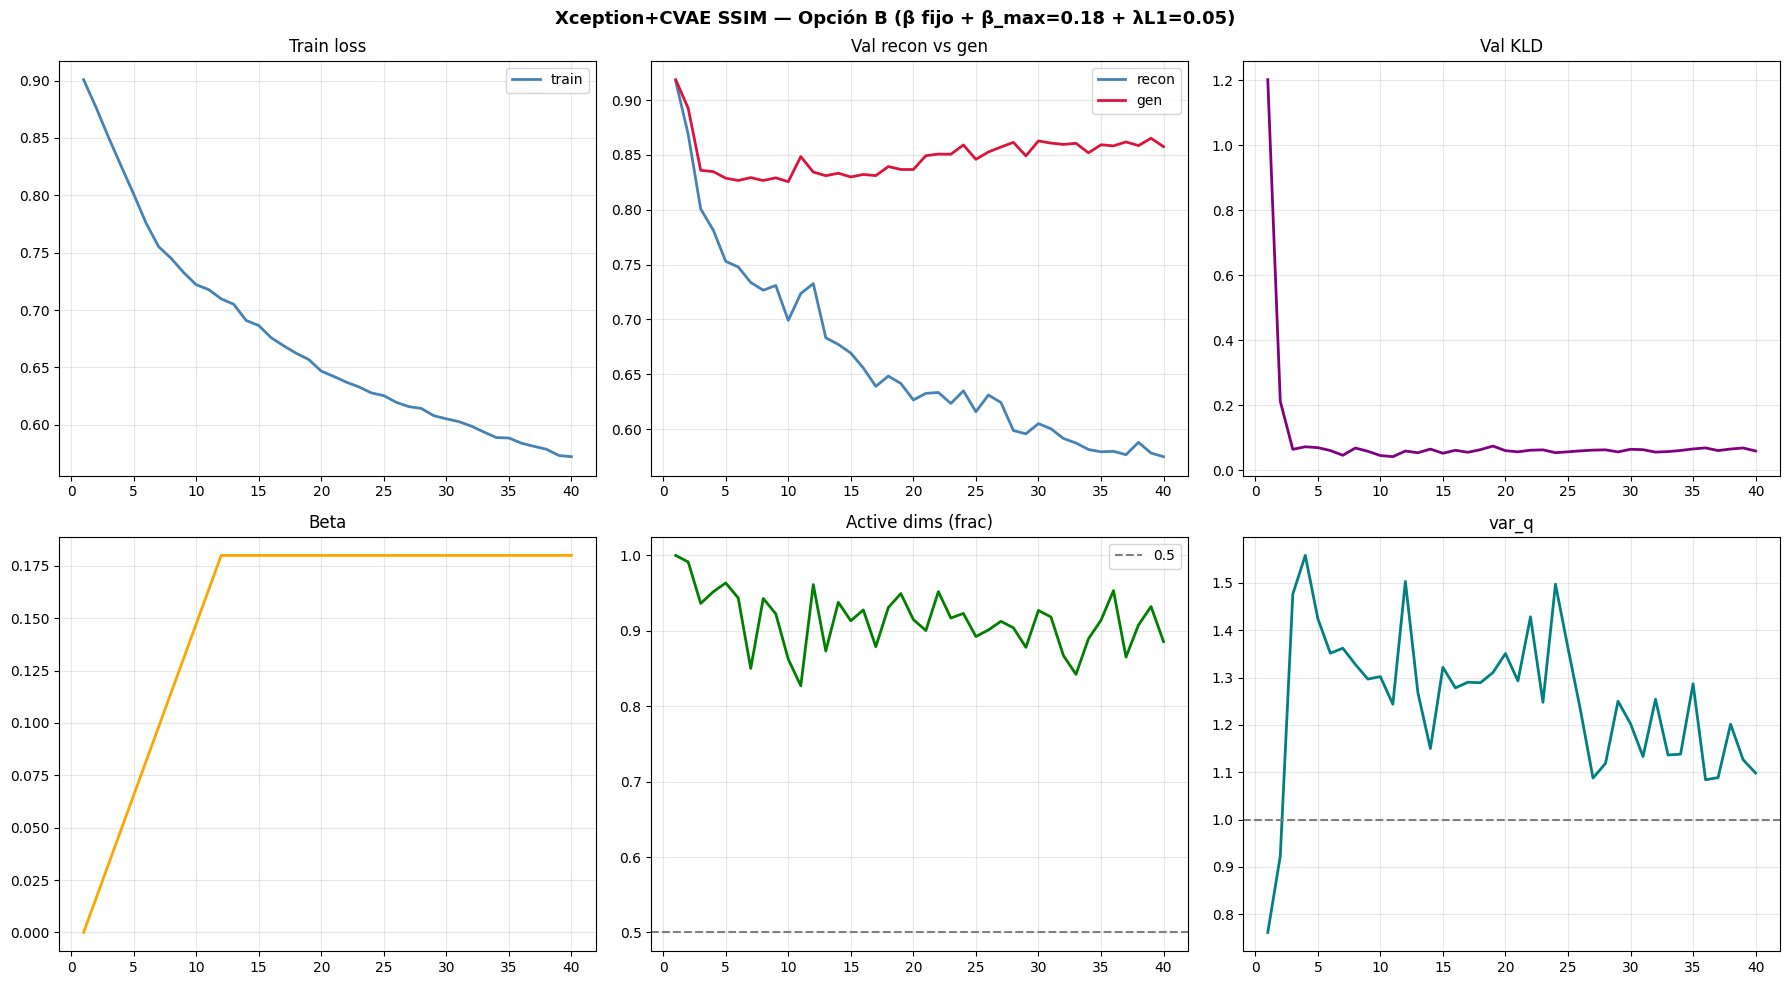

In [10]:
ep = range(1, len(hist["train_loss"]) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Xception+CVAE SSIM — Opción B (β fijo + β_max=0.18 + λL1=0.05)", fontsize=13, fontweight="bold")

axes[0, 0].plot(ep, hist["train_loss"], label="train", color="steelblue", lw=2)
axes[0, 0].set_title("Train loss"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep, hist["val_recon"], label="recon", color="steelblue", lw=2)
axes[0, 1].plot(ep, hist["val_gen"], label="gen", color="crimson", lw=2)
axes[0, 1].set_title("Val recon vs gen"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(ep, hist["val_kld"], color="purple", lw=2)
axes[0, 2].set_title("Val KLD"); axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(ep, hist["beta"], color="orange", lw=2)
axes[1, 0].set_title("Beta"); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep, hist["kl_active"], color="green", lw=2)
axes[1, 1].axhline(0.5, color="gray", ls="--", label="0.5")
axes[1, 1].set_title("Active dims (frac)"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(ep, hist["var_q"], color="teal", lw=2)
axes[1, 2].axhline(1.0, color="gray", ls="--")
axes[1, 2].set_title("var_q"); axes[1, 2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/curves_xception_optB.png", dpi=100)
plt.show()

## Visualización de reconstrucciones y generación

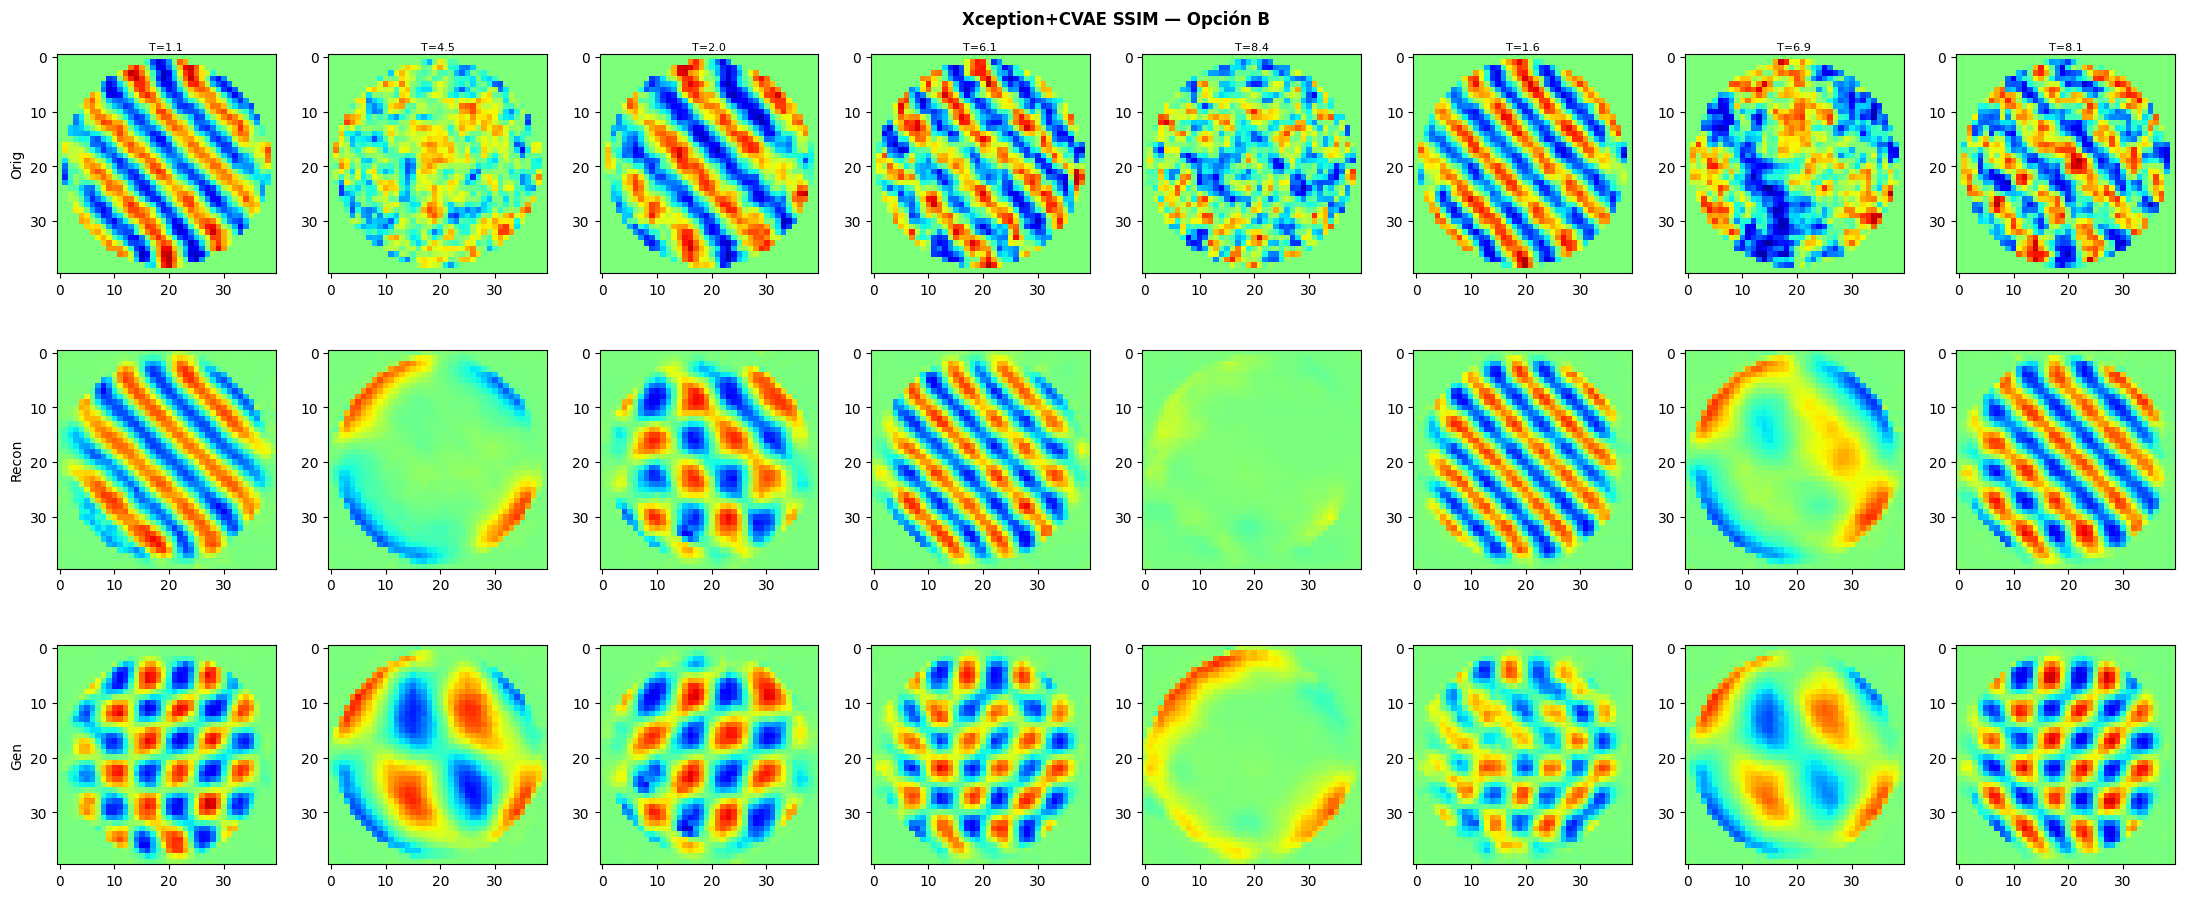

In [11]:
model.load_weights(CKPT_PATH)

n_show = 8
show_idx = np.random.choice(len(idx_val), n_show, replace=False)

fig = plt.figure(figsize=(2.8 * n_show, 2.8 * 3 + 0.6))
gs = plt.GridSpec(3, n_show, figure=fig, wspace=0.08, hspace=0.35,
                  left=0.02, right=0.98, top=0.92, bottom=0.02)

for col, si in enumerate(show_idx):
    real_idx = idx_val[si]
    img_raw = imgs_sub[real_idx:real_idx + 1]
    y_in = params_val[si:si + 1]

    img_40 = tf.image.resize(img_raw, (40, 40)).numpy()
    img_xc = tf.image.grayscale_to_rgb(tf.image.resize(img_raw, (224, 224)))

    x_hat, *_ = model([img_xc, y_in], training=False)
    x_gen = model.generate(y_in)

    orig = img_40[0, :, :, 0]
    recon = x_hat.numpy()[0, :, :, 0]
    gen = x_gen.numpy()[0, :, :, 0]

    y_orig = params_sub_raw[real_idx]
    tt = f"T={y_orig[0]:.1f}"

    for row, (im, lb) in enumerate(zip([orig, recon, gen], ["Orig", "Recon", "Gen"])):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(im, cmap="jet", vmin=-1, vmax=1, interpolation="nearest")
        ax.axis("on")
        if col == 0:
            ax.set_ylabel(lb, fontsize=10)
        if row == 0:
            ax.set_title(tt, fontsize=8, pad=3)

fig.suptitle("Xception+CVAE SSIM — Opción B", fontsize=12, fontweight="bold", y=0.97)
plt.savefig("/kaggle/working/reconstructions_xception_optB.png", dpi=100)
plt.show()

## Guardar pesos y resumen

In [12]:
FINAL_PATH = "/kaggle/working/cvae_xception_optB_last.weights.h5"
model.save_weights(FINAL_PATH)
print(f"Saved last: {FINAL_PATH}")
print(f"Saved best: {CKPT_PATH}")

with open("/kaggle/working/param_scaler_xception_optB.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved")

# guardar histórico
with open("/kaggle/working/history_xception_optB.json", "w") as f:
    json.dump(hist, f, indent=2)
print("History saved")

gr = hist["val_gen"][-1] / (hist["val_recon"][-1] + 1e-8)
print(f"\n{'='*60}")
print(f"RESUMEN — Xception + CVAE + SSIM (Opción B)")
print(f"{'='*60}")
print(f"  Val recon (last):  {hist['val_recon'][-1]:.4f}")
print(f"  Val gen   (last):  {hist['val_gen'][-1]:.4f}")
print(f"  Val gen   (best):  {best_gen:.4f}")
print(f"  Gap ratio:         {gr:.2f}x")
print(f"  Active dims:       {hist['kl_active'][-1]:.2f}")
print(f"  Var q:             {hist['var_q'][-1]:.3f}")
print(f"{'='*60}")

Saved last: /kaggle/working/cvae_xception_optB_last.weights.h5
Saved best: /kaggle/working/cvae_xception_optB.weights.h5
Scaler saved


TypeError: Object of type float32 is not JSON serializable